We can begin with the heatmap for displaying VTD decile

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path.cwd()
GOLD_DIR = BASE / "medallion" / "gold"
SILVER_DIR = BASE / "medallion" / "silver"
OUTPUT_DIR = BASE / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load tables
cp = pd.read_parquet(GOLD_DIR / "gold_customer_profiles.parquet")
co = pd.read_parquet(GOLD_DIR / "gold_customer_orders.parquet")
silver_orders = pd.read_parquet(SILVER_DIR / "silver_orders.parquet")

print(cp.columns)
print(co.columns)
print(silver_orders.columns)

Index(['customer_id', 'first_order_date', 'last_order_date', 'total_orders',
       'total_revenue', 'avg_order_value', 'total_discount_amt',
       'country_code', 'city', 'recency_days', 'acquisition_channel',
       'acquisition_country', 'acquisition_discount_code',
       'acquisition_discount_amt', 'acquisition_utm_source',
       'acquisition_utm_medium', 'acquisition_utm_campaign', 'rfm_group',
       'rfm_score', 'gender', 'is_repeat_customer', 'is_discount_acquired',
       'days_to_second_order', 'repeat_purchase_90d'],
      dtype='str')
Index(['order_id', 'order_name', 'customer_id', 'processed_at', 'channel',
       'Source', 'country_code', 'city', 'price_total', 'price_subtotal',
       'price_total_discount', 'price_total_shipping', 'price_total_refund',
       'payment_status', 'fulfillment_status', 'cancelled_at', 'cancel_reason',
       'utm_source', 'utm_medium', 'utm_campaign', 'discount_code',
       'discount_amount', 'order_sequence', 'is_first_order',
       '

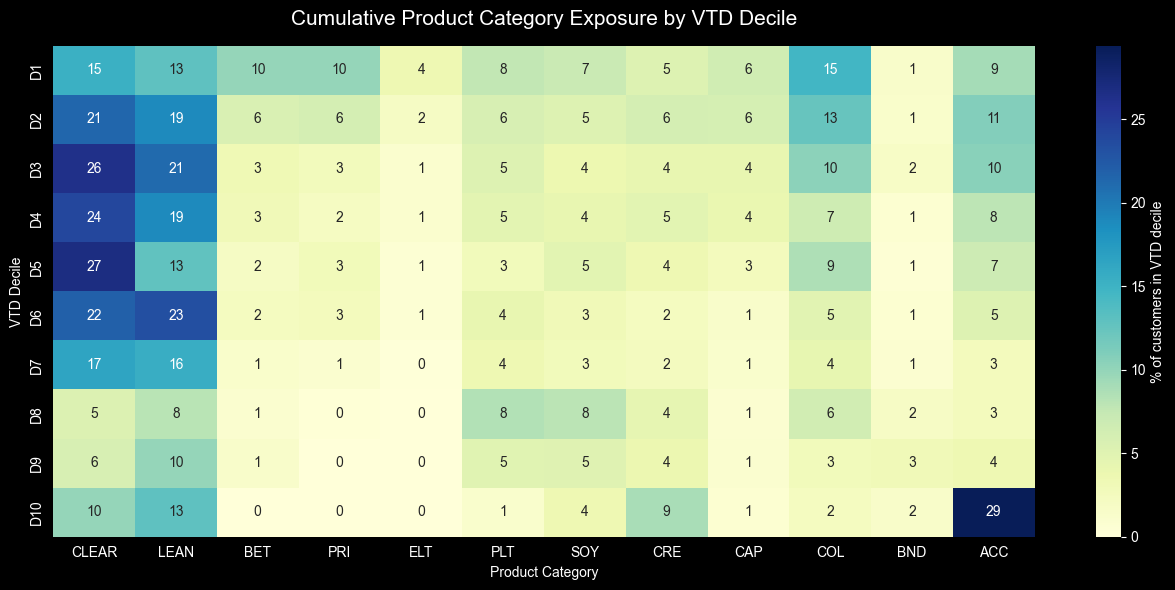

In [3]:
# -------------------------------
# Cumulative Category Heatmap by VTD Decile
# -------------------------------

# 1. Keep customer-level VTD
vtd = cp[["customer_id", "total_revenue"]].copy()
vtd = vtd[vtd["total_revenue"].notna()]
vtd = vtd[vtd["total_revenue"] > 0]

# 2. Create VTD deciles
# D1 = highest value customers, D10 = lowest value customers
vtd["vtd_decile"] = pd.qcut(
    vtd["total_revenue"].rank(method="first", ascending=False),
    10,
    labels=[f"D{i}" for i in range(1, 11)]
)

# 3. Extract category from SKU prefix in line items
line_items = silver_orders[silver_orders["Line: Type"] == "Line Item"].copy()

line_items["product_category"] = (
    line_items["Line: Variant SKU"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.split("-")
    .str[0]
)

# 4. Map silver order ID to gold order/customer table
# In the existing notebook, silver order ID maps to co.order_id
order_customer = co[["order_id", "customer_id"]].drop_duplicates()

line_items = line_items.merge(
    order_customer,
    left_on="ID",
    right_on="order_id",
    how="inner"
)

# 5. Customer-category exposure
# One row = customer x category they have ever bought
customer_category = (
    line_items[["customer_id", "product_category"]]
    .dropna()
    .drop_duplicates()
)

# 6. Attach VTD decile to customer-category exposure
customer_category = customer_category.merge(
    vtd[["customer_id", "vtd_decile"]],
    on="customer_id",
    how="inner"
)

# 7. Count customers per decile
decile_sizes = (
    vtd
    .groupby("vtd_decile", observed=False)["customer_id"]
    .nunique()
)

# 8. Calculate % of customers in each decile who bought each category
heatmap_data = (
    customer_category
    .groupby(["vtd_decile", "product_category"], observed=False)["customer_id"]
    .nunique()
    .unstack(fill_value=0)
)

heatmap_pct = heatmap_data.div(decile_sizes, axis=0) * 100

# 9. Optional: keep major categories only
major_categories = ["CLEAR", "LEAN", "BET", "PRI", "ELT", "PLT", "SOY", "CRE", "CAP", "COL", "BND", "ACC"]
existing_categories = [c for c in major_categories if c in heatmap_pct.columns]

heatmap_pct = heatmap_pct[existing_categories]

# 10. Plot heatmap
plt.figure(figsize=(13, 6))
sns.heatmap(
    heatmap_pct,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    cbar_kws={"label": "% of customers in VTD decile"}
)

plt.title("Cumulative Product Category Exposure by VTD Decile", fontsize=15, pad=15)
plt.xlabel("Product Category")
plt.ylabel("VTD Decile")
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "alex_vtd_decile_category_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()



This heatmap answers the question of: For each VTD decile, what percentage of customers have ever purchased each product category
- The VTD decile ranks customers by total value to date
- For example, D1 x Clear = 15. This means of 15% of the customers belonging in the first decile have made a purchase of product category CLEAR at least once
- Also D10 x ACC = 29, this means that over 29% of D10 customers have purchased accesories at least once


Now we will do the Annual Product Evolution, this should aim to show to the product mix has changed by year
-

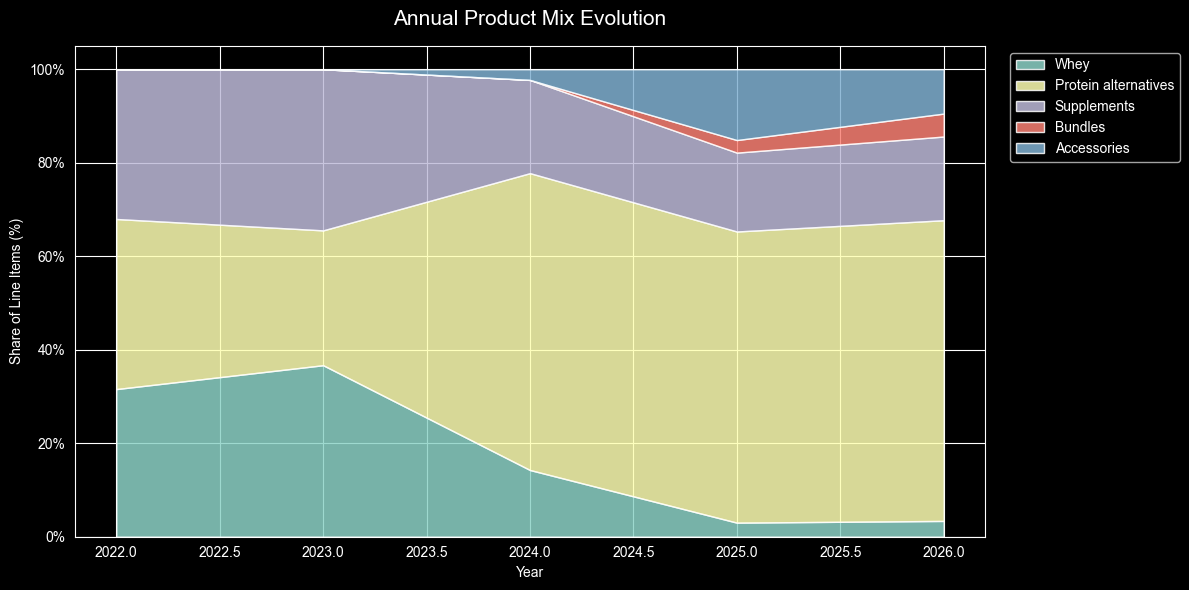

category_family,Whey,Protein alternatives,Supplements,Bundles,Accessories
year,,,,,
2022,0.315789,0.363844,0.320366,0.000000,0.000000
2023,0.366868,0.288397,0.344735,0.000000,0.000000
2024,0.142695,0.634982,0.199410,0.000000,0.022913
2025,0.030109,0.622785,0.168695,0.026906,0.151505
2026,0.033789,0.643202,0.179002,0.049075,0.094932


In [4]:
# -------------------------------
# Annual Product Evolution Chart
# -------------------------------

# Make sure order dates are available
orders_dates = co[["order_id", "processed_at"]].drop_duplicates().copy()
orders_dates["year"] = pd.to_datetime(orders_dates["processed_at"]).dt.year

line_items_year = line_items.merge(
    orders_dates,
    left_on="ID",
    right_on="order_id",
    how="inner",
    suffixes=("", "_order")
)

# Clean categories
line_items_year = line_items_year[line_items_year["product_category"].notna()].copy()

# Optional: group Whey-style categories together
def category_family(cat):
    if cat in ["BET", "PRI", "ELT"]:
        return "Whey"
    elif cat in ["CLEAR", "LEAN", "PLT", "SOY"]:
        return "Protein alternatives"
    elif cat in ["CRE", "CAP", "COL"]:
        return "Supplements"
    elif cat == "BND":
        return "Bundles"
    elif cat == "ACC":
        return "Accessories"
    else:
        return "Other"

line_items_year["category_family"] = line_items_year["product_category"].apply(category_family)

# Annual mix based on line-item count
annual_mix = (
    line_items_year
    .groupby(["year", "category_family"])
    .size()
    .reset_index(name="line_items")
)

annual_mix["share"] = (
    annual_mix["line_items"] /
    annual_mix.groupby("year")["line_items"].transform("sum")
)

annual_pivot = annual_mix.pivot(
    index="year",
    columns="category_family",
    values="share"
).fillna(0)

# Keep readable order
family_order = ["Whey", "Protein alternatives", "Supplements", "Bundles", "Accessories", "Other"]
annual_pivot = annual_pivot[[c for c in family_order if c in annual_pivot.columns]]

# Plot stacked area chart
plt.figure(figsize=(12, 6))
plt.stackplot(
    annual_pivot.index,
    [annual_pivot[col] * 100 for col in annual_pivot.columns],
    labels=annual_pivot.columns,
    alpha=0.85
)

plt.title("Annual Product Mix Evolution", fontsize=15, pad=15)
plt.xlabel("Year")
plt.ylabel("Share of Line Items (%)")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "alex_annual_product_mix_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

annual_pivot

The main trend is: Whey was much more important in 2022 - 2023, but its share collapsed from 2024 onward. At the same time Protein Alternatives become the dominant category. Supplements stay relevant while Accessories and Bundles appear more clearly in later years. Basically. the brand has moved away from being heavily whey centered and toward a broader product portfolio, especially protein alternatives, supplements, accesories and bundles.

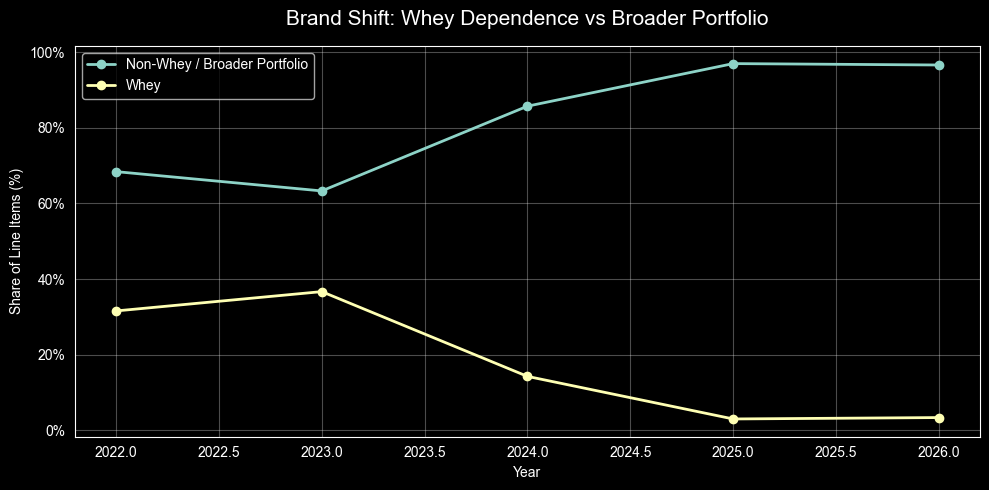

whey_flag,Non-Whey / Broader Portfolio,Whey
year,,
2022,0.684211,0.315789
2023,0.633132,0.366868
2024,0.857305,0.142695
2025,0.969891,0.030109
2026,0.966211,0.033789


In [5]:
# -------------------------------
# Whey vs Non-Whey Evolution
# -------------------------------

line_items_year["whey_flag"] = np.where(
    line_items_year["product_category"].isin(["BET", "PRI", "ELT"]),
    "Whey",
    "Non-Whey / Broader Portfolio"
)

whey_mix = (
    line_items_year
    .groupby(["year", "whey_flag"])
    .size()
    .reset_index(name="line_items")
)

whey_mix["share"] = (
    whey_mix["line_items"] /
    whey_mix.groupby("year")["line_items"].transform("sum")
)

whey_pivot = whey_mix.pivot(
    index="year",
    columns="whey_flag",
    values="share"
).fillna(0)

plt.figure(figsize=(10, 5))

for col in whey_pivot.columns:
    plt.plot(
        whey_pivot.index,
        whey_pivot[col] * 100,
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("Brand Shift: Whey Dependence vs Broader Portfolio", fontsize=15, pad=15)
plt.xlabel("Year")
plt.ylabel("Share of Line Items (%)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUT_DIR / "alex_whey_vs_nonwhey_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

whey_pivot

This second chart is the cleaner story chart: Whey and Non - Whey
Whey share:
- ~31% in 2022
- ~36% in 2023
- ~14% in 2024
- ~3% in 2025
- ~3% in 2026

Non-Whey share:
- ~69% in 2022
- ~64% in 2023
- ~86% in 2024
- ~97% in 2025
- ~97% in 2026
So it is not just that we diversified, it becomes overwhelmingly non whey by 2025 and 2026.
Whey became a much smaller share of total line items, because the overall product mix expanded or shifted toward other categories.